# Preprocessing Quality Control

This notebook helps us inspect whether the spectral preprocessing pipeline is improving signal quality without distorting chemically meaningful structure.

We will:
- load the real-data preprocessing configuration
- fit the preprocessor on the training split
- compare raw vs processed spectra on sampled examples
- compare aggregate train-split statistics before and after preprocessing
- inspect mean and variability patterns after cleaning

In [1]:
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'src').exists():
            return candidate
    raise RuntimeError('Could not locate the project root from the current notebook session.')

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from raman_classifier.config import load_config
from raman_classifier.data import ManifestDataModule
from raman_classifier.data.io import resample_spectrum
from raman_classifier.data.preprocessing import SpectralPreprocessor

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_rows', 200)

RAW_SPLIT_MAPPING = {
    'reference': ('train', 'reference'),
    'finetune': ('val', 'finetune'),
    'test': ('test', 'test'),
    '2018clinical': ('clinical_2018', 'clinical_2018'),
    '2019clinical': ('clinical_2019', 'clinical_2019'),
}

@dataclass
class InMemorySplitDataset:
    metadata: pd.DataFrame
    spectra: np.ndarray
    axis: np.ndarray
    target_length: int | None
    label_column: str = 'label'
    domain_column: str = 'domain'

    def __len__(self) -> int:
        return len(self.metadata)

    def load_raw_sample(self, index: int) -> tuple[np.ndarray, np.ndarray]:
        spectrum = np.asarray(self.spectra[int(index)], dtype=np.float32)
        return resample_spectrum(self.axis, spectrum, self.target_length)

def format_label_series(labels: np.ndarray) -> pd.Series:
    label_array = np.asarray(labels)
    if np.issubdtype(label_array.dtype, np.floating):
        finite_labels = label_array[np.isfinite(label_array)]
        if finite_labels.size == label_array.size and np.allclose(finite_labels, np.round(finite_labels)):
            label_array = np.round(label_array).astype(np.int64)
    return pd.Series(label_array).astype(str)

def build_numpy_qc_bundle(config: dict) -> SimpleNamespace:
    data_cfg = config['data']
    raw_dir = PROJECT_ROOT / 'data' / 'raw'
    axis_path = raw_dir / 'wavenumbers.npy'
    if not axis_path.exists():
        raise FileNotFoundError(f'Missing axis file required for QC: {axis_path}')

    axis = np.load(axis_path).astype(np.float32)
    target_length = data_cfg.get('target_length')
    label_column = data_cfg.get('label_column', 'label')
    sample_id_column = data_cfg.get('sample_id_column', 'sample_id')
    split_column = data_cfg.get('split_column', 'split')
    domain_column = data_cfg.get('domain_column', 'domain')

    datasets = {}
    metadata_frames = []

    for suffix, (split_name, domain_name) in RAW_SPLIT_MAPPING.items():
        spectra_path = raw_dir / f'X_{suffix}.npy'
        labels_path = raw_dir / f'y_{suffix}.npy'
        if not spectra_path.exists() or not labels_path.exists():
            continue

        spectra = np.load(spectra_path, mmap_mode='r')
        labels = np.load(labels_path, mmap_mode='r')
        if spectra.shape[0] != labels.shape[0]:
            raise ValueError(
                f'Mismatched sample counts for {suffix}: {spectra.shape[0]} spectra vs {labels.shape[0]} labels.'
            )

        split_metadata = pd.DataFrame({
            sample_id_column: [f'{suffix}_{index:06d}' for index in range(spectra.shape[0])],
            label_column: format_label_series(labels),
            split_column: split_name,
            domain_column: domain_name,
        })
        datasets[split_name] = InMemorySplitDataset(
            metadata=split_metadata.reset_index(drop=True),
            spectra=spectra,
            axis=axis,
            target_length=target_length,
            label_column=label_column,
            domain_column=domain_column,
        )
        metadata_frames.append(split_metadata)

    if not metadata_frames:
        raise FileNotFoundError(
            f'No raw NumPy archives were found in {raw_dir}. Expected files like X_reference.npy and y_reference.npy.'
        )

    train_split = data_cfg.get('train_split', 'train')
    if train_split not in datasets:
        raise FileNotFoundError(f"The training split '{train_split}' is unavailable in {raw_dir}.")

    metadata = pd.concat(metadata_frames, ignore_index=True)
    preprocessor = SpectralPreprocessor(data_cfg.get('preprocessing', {}))
    if preprocessor.requires_fit():
        train_dataset = datasets[train_split]
        if target_length is not None and int(target_length) != int(axis.shape[0]):
            train_spectra = np.stack([
                resample_spectrum(axis, np.asarray(sample, dtype=np.float32), target_length)[1]
                for sample in train_dataset.spectra
            ], axis=0)
        else:
            train_spectra = train_dataset.spectra
        preprocessor.fit(train_spectra)

    return SimpleNamespace(metadata=metadata, preprocessor=preprocessor, datasets=datasets)

CONFIG_PATH = PROJECT_ROOT / 'experiments' / 'configs' / 'real_base.yaml'
CONFIG_PATH

WindowsPath('S:/Raman_classification_project/experiments/configs/real_base.yaml')

## 1. Load Config And Data Module

The config defines the preprocessing recipe we want to evaluate. We fit the preprocessor only on the training split, which is what will also happen during model training.

In [2]:
config = load_config(CONFIG_PATH)
config['data']['preprocessing']

{'replace_non_finite': True,
 'clip_percentile': {'enabled': False, 'lower': 0.5, 'upper': 99.5},
 'baseline_correction': {'enabled': True,
  'method': 'asymmetric_least_squares',
  'lam': 100000.0,
  'p': 0.01,
  'niter': 10},
 'savgol': {'enabled': True, 'window_length': 11, 'polyorder': 3, 'deriv': 0},
 'snv': True,
 'standardize': False,
 'mean_center': False,
 'area_norm': False,
 'l2_norm': False,
 'minmax': False}

In [3]:
manifest_path = Path(config['data']['manifest_path'])
if manifest_path.exists():
    print(f'Using prepared manifest dataset: {manifest_path}')
    data_module = ManifestDataModule(config)
    data_module.setup()
else:
    print(
        f'Prepared manifest dataset not found at {manifest_path}. '
        'Using the raw NumPy archives under data/raw for notebook QC instead.'
    )
    data_module = build_numpy_qc_bundle(config)

train_split = config['data'].get('train_split', 'train')
train_dataset = data_module.datasets[train_split]
len(train_dataset)

Prepared manifest dataset not found at S:\Raman_classification_project\data\processed\archive_manifest\metadata.csv. Using the raw NumPy archives under data/raw for notebook QC instead.


60000

## 2. Split Summary

Before looking at preprocessing itself, it is useful to verify the dataset partitioning that the QC notebook is reading.

In [4]:
split_counts = (
    data_module.metadata.groupby(config['data'].get('split_column', 'split'))
    .size()
    .rename('num_samples')
    .reset_index()
)
display(split_counts)

,split,num_samples
0,clinical_2018,10000
1,clinical_2019,2500
2,test,3000
3,train,60000
4,val,3000


## 3. Sample Raw And Processed Spectra

We draw a random subset of training spectra and compare each raw signal to its processed version.

In [5]:
seed = int(config.get('seed', 42))
rng = np.random.default_rng(seed)
num_examples = min(6, len(train_dataset))
if num_examples == 0:
    raise ValueError(f"Split '{train_split}' is empty, so there are no spectra to visualize.")
indices = rng.choice(len(train_dataset), size=num_examples, replace=False)
indices

array([39272, 46434, 25980, 51515, 26331,  5354])

In [6]:
raw_axes = []
raw_spectra = []
processed_spectra = []
labels = []
domains = []

for index in indices:
    axis, raw_spectrum = train_dataset.load_raw_sample(int(index))
    processed = data_module.preprocessor.transform(raw_spectrum)
    record = train_dataset.metadata.iloc[int(index)]

    raw_axes.append(axis)
    raw_spectra.append(raw_spectrum)
    processed_spectra.append(processed)
    labels.append(record[train_dataset.label_column])
    domains.append(record[train_dataset.domain_column])

raw_spectra = np.stack(raw_spectra, axis=0)
processed_spectra = np.stack(processed_spectra, axis=0)

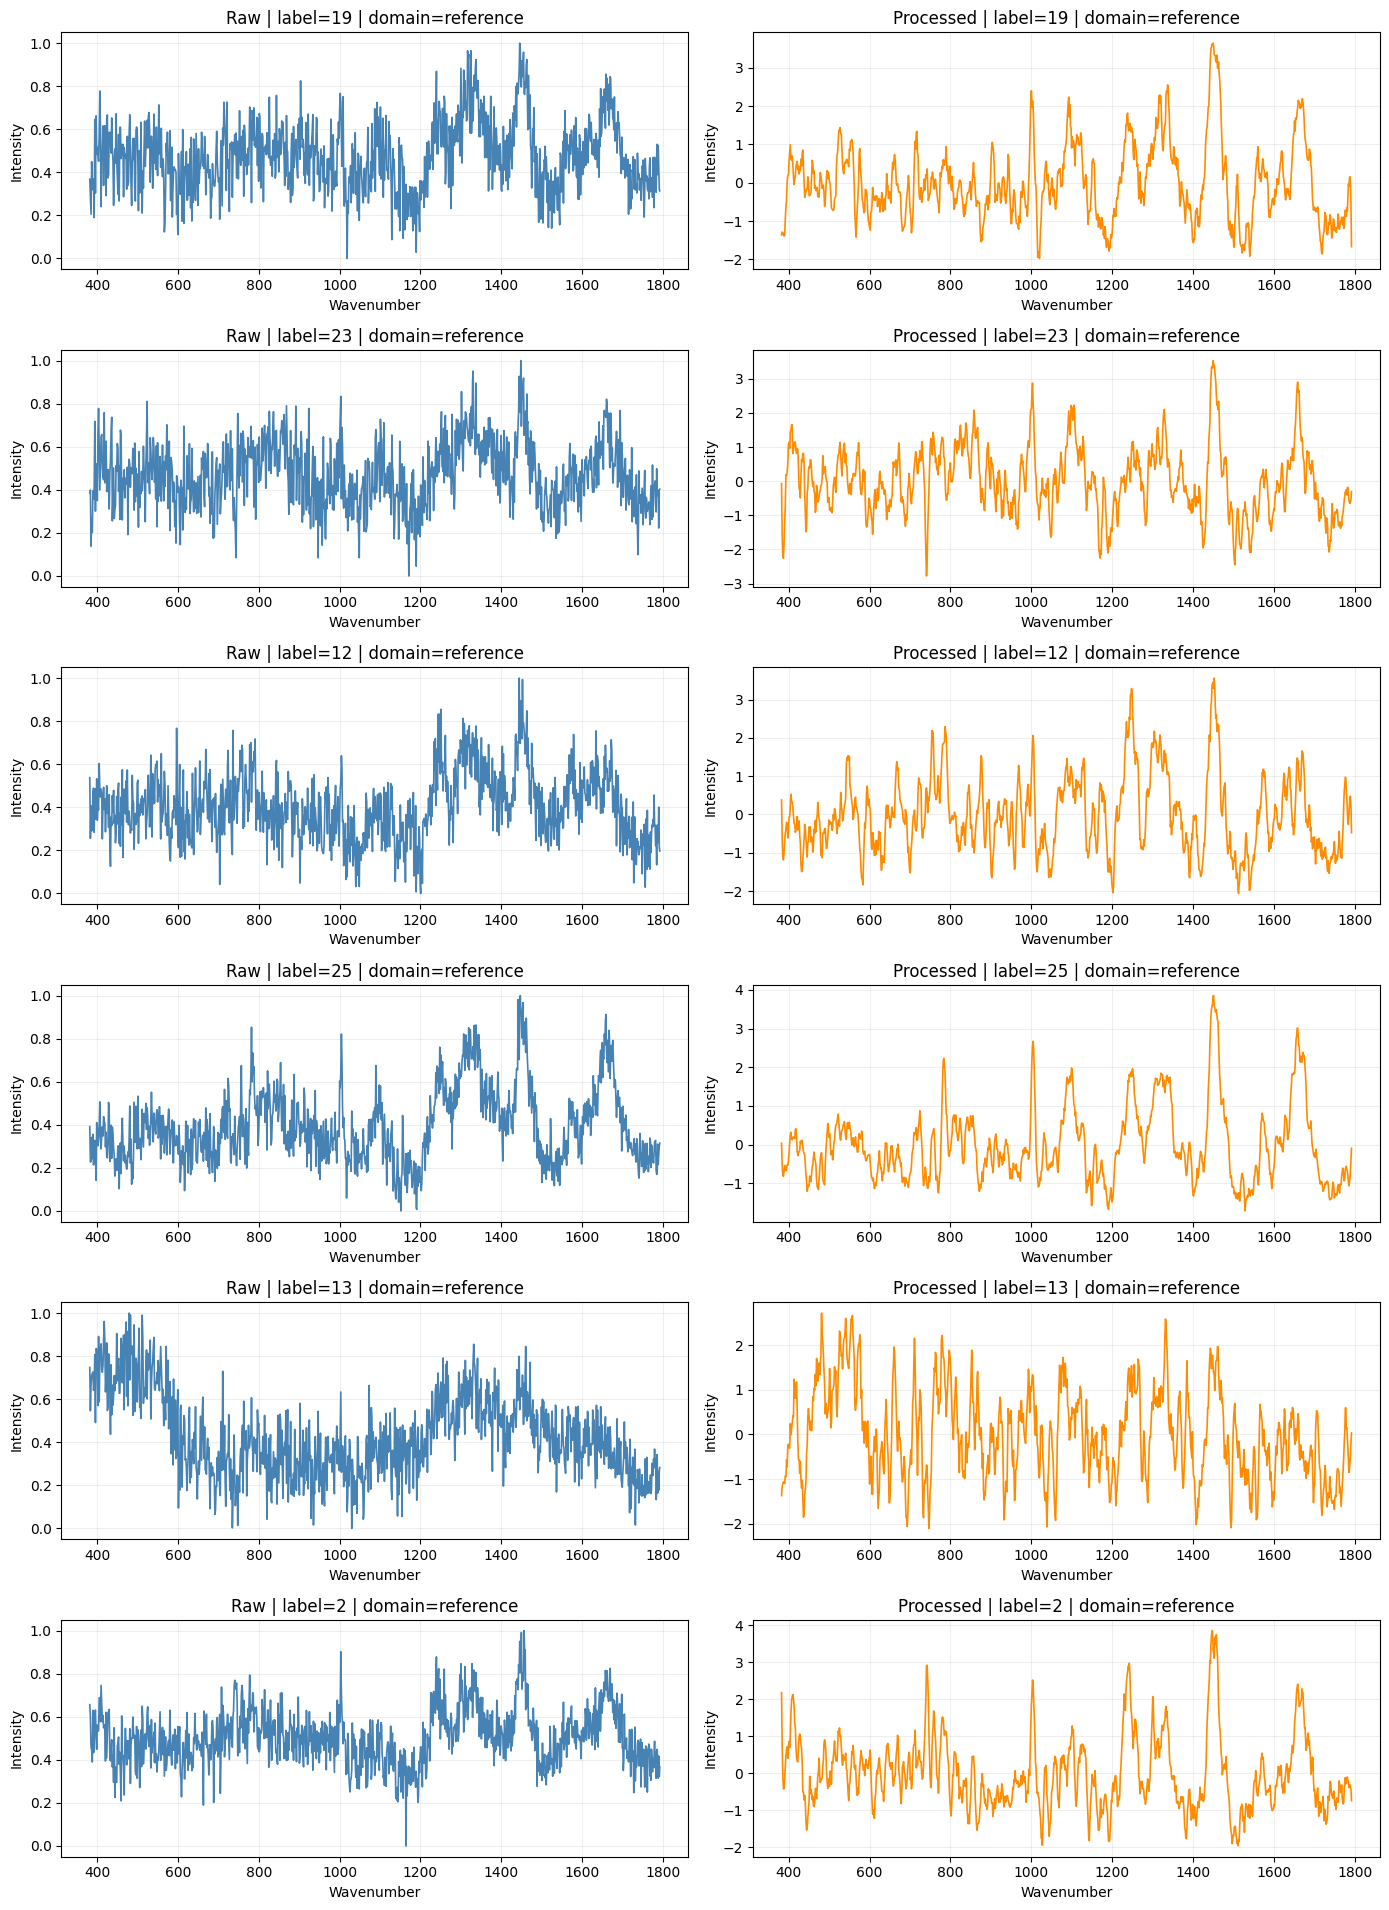

In [7]:
fig, axes = plt.subplots(num_examples, 2, figsize=(14, 3.2 * num_examples), squeeze=False)

for row in range(num_examples):
    axis = raw_axes[row]
    raw_spectrum = raw_spectra[row]
    processed = processed_spectra[row]
    label = labels[row]
    domain = domains[row]

    axes[row, 0].plot(axis, raw_spectrum, color='steelblue', linewidth=1.2)
    axes[row, 0].set_title(f'Raw | label={label} | domain={domain}')
    axes[row, 0].set_xlabel('Wavenumber')
    axes[row, 0].set_ylabel('Intensity')
    axes[row, 0].grid(alpha=0.2)

    axes[row, 1].plot(axis, processed, color='darkorange', linewidth=1.2)
    axes[row, 1].set_title(f'Processed | label={label} | domain={domain}')
    axes[row, 1].set_xlabel('Wavenumber')
    axes[row, 1].set_ylabel('Intensity')
    axes[row, 1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

## 4. Overlay Comparison

A side-by-side figure is useful, but an overlay makes it easier to see whether preprocessing is only smoothing / baseline-correcting the signal or whether it is removing true peaks.

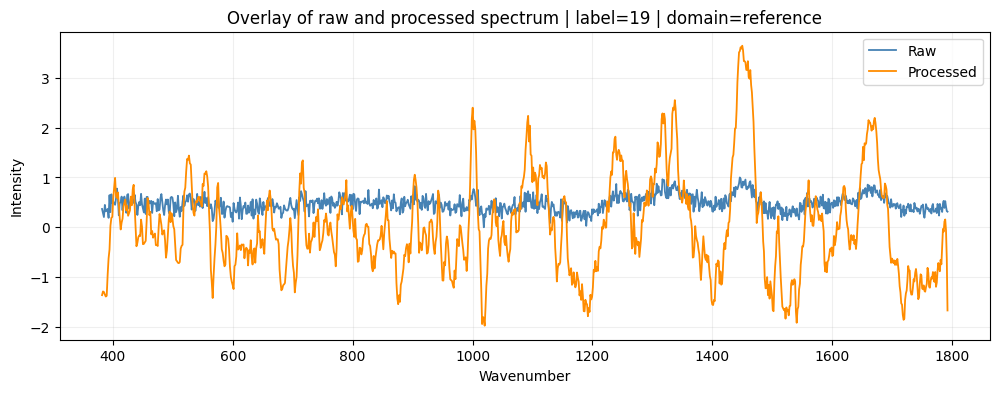

In [8]:
example_row = 0
axis = raw_axes[example_row]

plt.figure(figsize=(12, 4))
plt.plot(axis, raw_spectra[example_row], label='Raw', color='steelblue', linewidth=1.3)
plt.plot(axis, processed_spectra[example_row], label='Processed', color='darkorange', linewidth=1.3)
plt.title(f'Overlay of raw and processed spectrum | label={labels[example_row]} | domain={domains[example_row]}')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 5. Aggregate Statistics Before And After Preprocessing

We now move from a few examples to a larger sample from the training split. This gives us a more stable picture of how the preprocessing recipe changes scale, variability, and overall dynamic range.

In [9]:
sample_size = min(512, len(train_dataset))
sample_indices = rng.choice(len(train_dataset), size=sample_size, replace=False)

raw_batch = []
processed_batch = []
for index in sample_indices:
    _, raw_spectrum = train_dataset.load_raw_sample(int(index))
    processed = data_module.preprocessor.transform(raw_spectrum)
    raw_batch.append(raw_spectrum)
    processed_batch.append(processed)

raw_batch = np.stack(raw_batch, axis=0)
processed_batch = np.stack(processed_batch, axis=0)
raw_batch.shape, processed_batch.shape

((512, 1000), (512, 1000))

In [10]:
def compute_stats(spectra: np.ndarray) -> dict:
    row_means = spectra.mean(axis=1)
    row_stds = spectra.std(axis=1)
    return {
        'num_samples': int(spectra.shape[0]),
        'num_features': int(spectra.shape[1]),
        'global_min': float(spectra.min()),
        'global_max': float(spectra.max()),
        'mean_of_row_means': float(row_means.mean()),
        'std_of_row_means': float(row_means.std()),
        'mean_of_row_stds': float(row_stds.mean()),
        'std_of_row_stds': float(row_stds.std()),
    }

stats_df = pd.DataFrame([
    {'stage': 'raw', **compute_stats(raw_batch)},
    {'stage': 'processed', **compute_stats(processed_batch)},
])
display(stats_df)

,stage,num_samples,num_features,global_min,global_max,mean_of_row_means,std_of_row_means,mean_of_row_stds,std_of_row_stds
0,raw,512,1000,0.000000,1.000000,4.307427e-01,8.475409e-02,0.156621,0.016365
1,processed,512,1000,-3.667483,8.006236,2.209562e-09,8.600063e-08,0.999990,0.000002


## 6. Mean Spectrum And Variability Envelope

This view is very useful for checking whether the preprocessing pipeline reduces nuisance variation while preserving consistent peak structure across the training set.

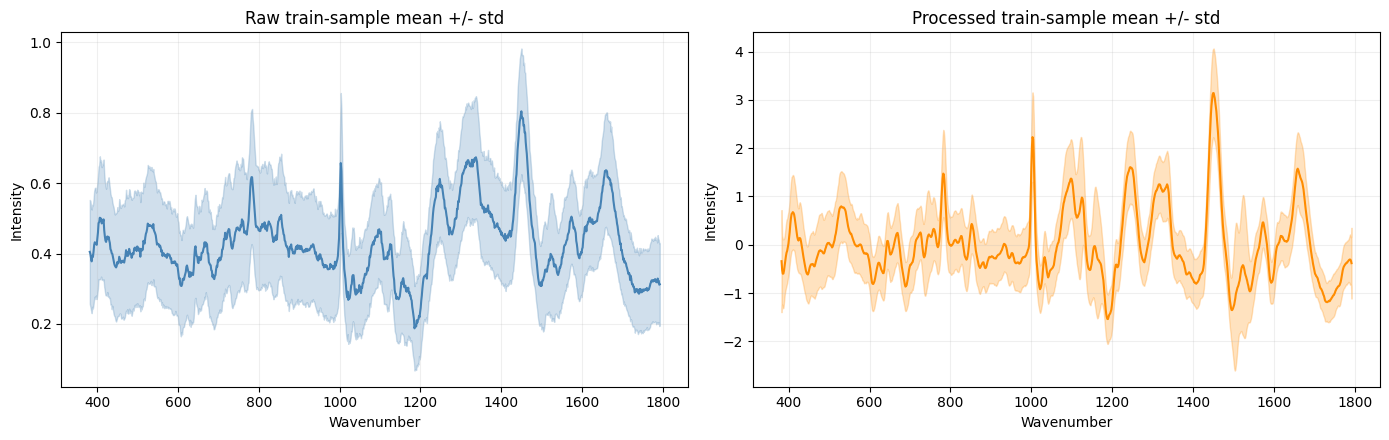

In [11]:
axis = raw_axes[0]
raw_mean = raw_batch.mean(axis=0)
raw_std = raw_batch.std(axis=0)
processed_mean = processed_batch.mean(axis=0)
processed_std = processed_batch.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

axes[0].plot(axis, raw_mean, color='steelblue', linewidth=1.5)
axes[0].fill_between(axis, raw_mean - raw_std, raw_mean + raw_std, color='steelblue', alpha=0.25)
axes[0].set_title('Raw train-sample mean +/- std')
axes[0].set_xlabel('Wavenumber')
axes[0].set_ylabel('Intensity')
axes[0].grid(alpha=0.2)

axes[1].plot(axis, processed_mean, color='darkorange', linewidth=1.5)
axes[1].fill_between(axis, processed_mean - processed_std, processed_mean + processed_std, color='darkorange', alpha=0.25)
axes[1].set_title('Processed train-sample mean +/- std')
axes[1].set_xlabel('Wavenumber')
axes[1].set_ylabel('Intensity')
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

## 7. Difference View

A difference plot helps us see where the preprocessing is acting most strongly. Large smooth changes often indicate baseline removal, while very high-frequency changes usually reflect smoothing.

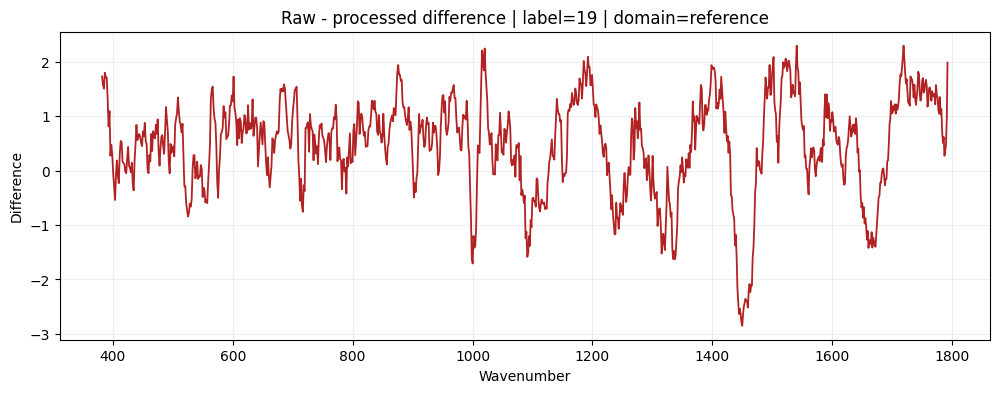

In [12]:
difference = raw_spectra[example_row] - processed_spectra[example_row]

plt.figure(figsize=(12, 4))
plt.plot(axis, difference, color='firebrick', linewidth=1.3)
plt.title(f'Raw - processed difference | label={labels[example_row]} | domain={domains[example_row]}')
plt.xlabel('Wavenumber')
plt.ylabel('Difference')
plt.grid(alpha=0.2)
plt.show()

## 8. Interpretation Checklist

When reviewing the plots above, the preprocessing is usually doing the right thing if:

- baseline drift is reduced
- random high-frequency jaggedness is slightly reduced
- major Raman peaks remain visible and are not flattened away
- relative shape differences between classes still look plausible
- the processed signals do not look unnaturally clipped or overly standardized

Red flags would be:

- peaks disappear completely
- all spectra become nearly identical in shape
- strong oscillations are introduced by smoothing or derivatives
- intensity scaling becomes dominated by preprocessing artifacts rather than spectral structure

## 9. Next Step

If the processed spectra still preserve meaningful peak structure while looking cleaner and more consistent than the raw spectra, we can lock this preprocessing recipe and train the first CNN baseline on the real dataset.

In [1]:
import matplotlib.pyplot as plt

# Pick a random sample
sample = X_reference[0]

# Apply preprocessing
processed = preprocess_signal(sample)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(sample, label="Raw", alpha=0.6)
plt.plot(processed, label="Processed", linewidth=2)

plt.title("Before vs After Preprocessing")
plt.legend()
plt.show()

NameError: name 'X_reference' is not defined

In [ ]:
for i in range(5):
    plt.plot(preprocess_signal(X_reference[i]))

plt.title("Processed Samples")
plt.show()